In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy.signal import welch

# Paros QC

Steps, in the order they are applied:
1. decode the raw counts to absolute pressure (psia) and temperature with the Paroscientific calibration in `header.dat`; check against the logger's own `PAR*.DAT`
2. clock drift correction (whole raw record)
3. atmospheric correction with the NOAA 1612340 (Honolulu Harbor) barometer (the in-air offset is measured and stored, not applied)
4. trim to the in-water window
5. per-sample decode flag and per-hour (= per file) segment flags `seg_ok`
6. save `{SITE}_QC.nc`



### 0. Sensor selection and parameters
Every section reads `sensor_id` from the cell below. The batch cell at the end runs this notebook once per site in `SENSORS`.

In [2]:
##-----sensor selection-----##
sensor_id = "PB1"
# Sites for the batch cell at the end of the notebook. Folder -> site (sensor_notes.csv): P1 PB1, P2 PB2, P3 PC1,
# P4 PE1 (deployed as "P6"), P6 PD1 (deployed as "P5"). P5 was a practice unit and is not deployed.
SENSORS = ["PB1", "PB2", "PC1", "PD1", "PE1"]

##-----parameters-----##
# Everything tunable lives here.
# section 1: decode
FS_NOM     = 2.0      # Hz. Sampling rate (SETUP.DAT). Files hold 7167 samples after the zero first record (3583.5 s),
                      # then there is a ~16.5 s gap until the next file. fs = 2 Hz exactly (checked, see 1b).
GATE_S     = 0.45     # s. Gate time of the period counter; the tick count is gate_s * f_clock
PSI2DBAR   = 0.6894757  # 1 psi = 6894.757 Pa = 0.6894757 dbar
PAR_TOL_PSI, PAR_TOL_C = 3e-4, 5e-3   # accepted |decoded - PAR*.DAT|

# section 2: clock drift
DRIFT_OVERRIDE = {}   # s (+ = sensor clock fast) that replace a value in sensor_notes.csv, as in adv_QC

# section 3: atmosphere
APPLY_AIR_OFFSET = False  # True subtracts the pre-deployment in-air offset C_pre. Off: the in-air reading depends on where the unit sat
                          # (pre and post-recovery differ by 11-15 cm and the sensor order flips), so it is stored as a diagnostic only
P_AIR        = 0.05   # dbar. Gauge pressure below this = in air (wet is > 0.1 dbar even at the shallowest site)
AIR_MARGIN_MIN = 5    # min. In-air samples used for C stay this far from the splash / lift
RHO, GRAV    = 1023.0, 9.79   # kg/m3, m/s2 (21 N). Same as adv_QC: dbar -> m of water, 1 dbar = 1e4 Pa

# section 4: trim
P_WET        = 0.3    # dbar, tested on 1-MIN MEANS (not single samples) so swell troughs at the 1-3 m sites cannot split the record
BUFFER_S     = 10     # s taken off each end of the window
TRIM_EDGES   = {}     # {site: (start, end)} manual pressure edges, as in adv_QC. None needed so far

# section 5: segment flags (one segment per raw file = one hour)
N_FILE       = 7167   # samples in a full file
SEG_MIN_FRAC = 0.99   # a segment needs this fraction of N_FILE samples
GAP_MAX_S    = 2.0    # s. Largest gap INSIDE a segment (the 16.5 s file-to-file gap is between segments)
# Decode flag = tick-wrap count k differs from the record's modal value (a counter / unwrap error) or the decode is not finite.
# NOT a step threshold: bores on the reef flat give sample-to-sample steps up to 0.8 dbar (a smooth tail, no separate glitch
# population; pcorrect.m also notes "ringing at jumps/bores"), so max_step is stored per hour as a diagnostic only.
WELCH_NFFT   = 256    # samples (128 s), Hann, 50 % overlap, linear detrend: same as the ADV z2 section
F_SS         = (0.04, 0.25)   # Hz, sea-swell band for Hs_SS (same as the ADV QC)
Z_P_HAB      = {"default": 0.05, "PC1": -0.15}  # m, port above the bed, used only for depth_h = mean p + z_p.
                      # PC1 was found buried about 6 in (0.15 m) at recovery; the others sat on the bed (an ESTIMATE, as for the ADVs)

# nearest ADV, for the Hs diagnostic only (same transect)
NEAREST_ADV = {"PB1": "VB5", "PB2": "VB5", "PC1": "VC5", "PD1": "VD5", "PE1": "VE4"}

# paths: raw in, data/processed/qc/{site}_QC.nc out, figs/qc/paros/ for figures
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
root    = Path(data_path).parents[1]              # .../4EWA
qc_dir  = Path(data_path) / "qc"
fig_dir = root / "figs" / "qc" / "paros"
qc_dir.mkdir(exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# figure style (memory: simple, IndianRed + cobalt, no grid, no top/right spines)
RED, BLUE, OLIVE, INK = "indianred", "#0047AB", "#708238", "0.15"
plt.rcParams.update({
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 9, "lines.linewidth": 0.8,
})
sensor_id = "PB2"   # injected by the batch cell

### 1. Raw decode
#### 1a. Site lookup and calibration
`sensor_notes.csv` gives the logger folder (`Sensor Assignment`) and S/N for the site. The `PAR<serial>.DAT` file in the folder carries the serial, which must equal the CSV S/N with its leading 1 dropped (123626 is 23626). That guards the folder / site swaps (P4 is PE1, P6 is PD1).

`header.dat` holds 15-line blocks: serial, clock frequency $f$, $U_0$, $Y_1$–$Y_3$, $C_1$–$C_3$, $D_1$, $D_2$, $T_1$–$T_4$.

#### 1b. Counts to pressure
Each file holds 7168 records of four big-endian `uint16`: pressure cycles, low 16 bits of the pressure tick count, temperature cycles, low 16 bits of the temperature tick count. The first record is zeros and is dropped.
- Tick count: `ticks = lo + 65536 * round((GATE_S * f - lo) / 65536)` (the counter wraps every 65536).
- Periods (µs): $\tau_P = 10^6\,\mathrm{ticks}/(f\,N_P)$ and $\tau_T = 10^6\,\mathrm{ticks}/(2 f\,N_T)$.
- $U = \tau_T - U_0$; $C = C_1 + C_2 U + C_3 U^2$; $D = D_1 + D_2 U$; $T_0 = T_1 + T_2 U + T_3 U^2 + T_4 U^3$.
- $P = C\,(1 - T_0^2/\tau_P^2)\,[1 - D\,(1 - T_0^2/\tau_P^2)]$ in psia (absolute); $T = Y_1 U + Y_2 U^2 + Y_3 U^3$ in °C.

Sample $i$ of a file (after dropping the zero record) is stamped `file_start + i / 2 Hz`. Files start on the hour, and the 7167 samples cover 3583.5 s. A within-hour cross-correlation of PE1 against VE4 (first vs last 15 min of 29 well-correlated hours) gave a lag difference of $0.0 \pm 0.5$ s, where a 1.991 Hz clock would have given about 16 s. So fs is 2 Hz with a gap at the end of each file. Whether the zero record is the sample at the file start or the one before it is a 0.5 s question and is ignored.

In [3]:
##-----site lookup + calibration-----##
notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
folder = row["Sensor Assignment"].strip()                 # logger folder, e.g. P4 for PE1
sn_csv = row["S/N"].strip()
raw_dir = root / "data" / "raw" / "Paros" / folder
ext = "MP" + folder[1:]

par_file = next(raw_dir.glob("PAR*.DAT"))
serial = int(par_file.stem[3:])
assert str(serial) == sn_csv[1:], f"{sensor_id}: PAR file serial {serial} != CSV S/N {sn_csv} (without its leading 1)"

lines = [l.strip() for l in open(raw_dir / "header.dat") if l.strip()]
names = ["serial", "f", "U0", "Y1", "Y2", "Y3", "C1", "C2", "C3", "D1", "D2", "T1", "T2", "T3", "T4"]
blocks = [dict(zip(names, map(float, lines[i:i + 15]))) for i in range(0, len(lines) - 14, 15)]
cal = next(b for b in blocks if int(b["serial"]) == serial)
print(f"{sensor_id}: folder {folder}, S/N {serial}, {len(blocks)} calibration blocks in header.dat")
print({k: v for k, v in cal.items()})

def decode(raw, c):
    # raw: (n, 4) uint16 records WITHOUT the zero first record -> psia, degC, tick-wrap count k
    raw = raw.astype(float)
    f = c["f"]
    kp = np.round((GATE_S * f - raw[:, 1]) / 65536)
    kt = np.round((GATE_S * f - raw[:, 3]) / 65536)
    with np.errstate(divide="ignore", invalid="ignore"):
        tau_p = (raw[:, 1] + 65536 * kp) / (f * raw[:, 0]) * 1e6
        tau_t = (raw[:, 3] + 65536 * kt) / (f * 2 * raw[:, 2]) * 1e6
        U = tau_t - c["U0"]
        Cc = c["C1"] + c["C2"] * U + c["C3"] * U**2
        D = c["D1"] + c["D2"] * U
        T0 = c["T1"] + c["T2"] * U + c["T3"] * U**2 + c["T4"] * U**3
        x = 1 - T0**2 / tau_p**2
        P = Cc * x * (1 - D * x)
    T = c["Y1"] * U + c["Y2"] * U**2 + c["Y3"] * U**3
    P[~np.isfinite(P)] = np.nan
    return P, T, kp

# check against the logger's own converted file: find the raw file whose counts match PAR*.DAT
par = np.loadtxt(par_file)                       # psi, degC, Pcyc, Ptick_lo, Tcyc, Ttick_lo
checked = None
for fn in sorted(raw_dir.glob("*.M?" + folder[1:])):
    if fn.stat().st_size == 0:
        continue
    d = np.fromfile(fn, dtype=">u2").reshape(-1, 4)[1:]
    if len(d) == len(par) and np.array_equal(d[:5], par[:5, 2:].astype(int)):
        P_chk, T_chk, _ = decode(d, cal)
        checked = (fn.name, np.nanmax(np.abs(P_chk - par[:, 0])), np.nanmax(np.abs(T_chk - par[:, 1])))
        break
assert checked is not None, f"no raw file matches {par_file.name}"
print(f"decode check vs {par_file.name}: matches {checked[0]}, max |dP| {checked[1]:.1e} psi, max |dT| {checked[2]:.1e} degC")
assert checked[1] < PAR_TOL_PSI and checked[2] < PAR_TOL_C

PB2: folder P2, S/N 35605, 82 calibration blocks in header.dat
{'serial': 35605.0, 'f': 4096000.0, 'U0': 5.851903, 'Y1': -3945.249, 'Y2': -9731.114, 'Y3': 0.0, 'C1': 225.5831, 'C2': 5.227356, 'C3': -319.1442, 'D1': 0.037619, 'D2': 0.0, 'T1': 27.91223, 'T2': 0.96011, 'T3': 20.81312, 'T4': 26.7631}
decode check vs PAR35605.DAT: matches 07220500.MT2, max |dP| 7.6e-05 psi, max |dT| 2.0e-03 degC


In [4]:
##-----load all hourly files-----##
files = sorted(f for f in raw_dir.glob("*." + ext) if f.stat().st_size > 0)   # 0-byte first/last files are empty
P_list, T_list, t_list, fidx_list, k_list = [], [], [], [], []   # k_list: tick-wrap count per sample
for i, fn in enumerate(files):
    d = np.fromfile(fn, dtype=">u2").reshape(-1, 4)[1:]        # drop the zero first record
    P, T, kp = decode(d, cal)
    t0 = pd.Timestamp(f"2026-{fn.name[0:2]}-{fn.name[2:4]} {fn.name[4:6]}:{fn.name[6:8]}")
    P_list.append(P); T_list.append(T); k_list.append(kp.astype(np.int16))
    t_list.append(t0.to_datetime64() + (np.arange(len(P)) * 1e9 / FS_NOM).astype("timedelta64[ns]"))
    fidx_list.append(np.full(len(P), i, dtype=np.int32))
P_psi = np.concatenate(P_list)
temp  = np.concatenate(T_list)
t_raw = np.concatenate(t_list)
fidx  = np.concatenate(fidx_list)
file_start = np.array([np.datetime64(f"2026-{f.name[0:2]}-{f.name[2:4]}T{f.name[4:6]}:{f.name[6:8]}") for f in files], dtype="datetime64[ns]")
k_wrap = np.concatenate(k_list)
kk_nz = dict(zip(*[a.tolist() for a in np.unique(k_wrap, return_counts=True)]))
k_mode = int(max(kk_nz, key=kk_nz.get))
print(f"{len(files)} files, {len(P_psi):,} samples, {file_start[0]} -> {file_start[-1]}")
print(f"tick-wrap counts k (samples per value): {kk_nz} (modal {k_mode});  NaN pressure: {np.isnan(P_psi).sum()}")

1414 files, 10,134,138 samples, 2026-07-23T04:00:00.000000000 -> 2026-09-20T01:00:00.000000000
tick-wrap counts k (samples per value): {28: 10134138} (modal 28);  NaN pressure: 0


### 2. Clock drift correction
Linear drift from 0 at the first raw sample to the value in `sensor_notes.csv` at the last, subtracted from the timestamps, exactly as in `adv_QC.ipynb`: **+ = sensor clock fast**, $t_\mathrm{true} = t - \mathrm{drift}\cdot\mathrm{frac}$. The notes footnote gives the same convention (negative = slower than PC time). `process_paros.m` has the opposite wording ("negative: paros is fast") for its own drift table, so do not carry its signs over. The Paros drifts are a few seconds in 8 weeks.
The raw `t_raw` stays as the file-hour label of each segment (section 5).

In [5]:
##-----clock drift: linear correction-----##
drift_str = row["Clock Drift (seconds) over Deployment Duration***"].strip()
if sensor_id in DRIFT_OVERRIDE:
    drift = float(DRIFT_OVERRIDE[sensor_id])
    print(f"{sensor_id}: DRIFT_OVERRIDE {drift:+.3f} s replaces the CSV value '{drift_str}'")
else:
    assert not drift_str.endswith("*"), f"{sensor_id} drift '{drift_str}' is footnoted; check sensor_notes.csv"
    drift = float(drift_str)        # s; + = sensor clock fast, - = slow (CSV convention)

t_raw0, t_raw1 = t_raw[0], t_raw[-1]
frac  = (t_raw - t_raw0) / (t_raw1 - t_raw0)          # 0 at clock set -> 1 at drift check
t = t_raw - np.round(drift * frac * 1e9).astype("timedelta64[ns]")
print(f"{sensor_id}: drift {drift:+.3f} s over {(t_raw1 - t_raw0) / np.timedelta64(1, 'D'):.2f} days "
      f"(shift {drift * frac[0]:+.3f} -> {drift * frac[-1]:+.3f} s)")

PB2: drift -5.000 s over 58.92 days (shift -0.000 -> -5.000 s)


### 3. Atmospheric pressure
The Paros read **absolute** pressure, so unlike the Vectors there is no sensor-internal offset to find: $p = P_\mathrm{abs} - P_\mathrm{atm}(t)$. The barometer is NOAA CO-OPS 1612340 (Honolulu Harbor), hourly, hPa, GMT (`data/metadata/noaa_1612340_air_pressure.csv`, the same file `adv_QC.ipynb` uses; the copy in the project root has identical values). It is linearly interpolated to every sample. This assumes the (drift-corrected) Paros clock is UTC; section 4b checks that.

**In-air offset: measured, stored, NOT applied (`APPLY_AIR_OFFSET = False`).** After the Honolulu correction every Paros reads $-4$ to $-6$ cm of water in air before deployment, and $+6$ to $+9$ cm after recovery. The two differ by 11–15 cm on every unit, which cannot be sensor drift over 7 weeks, and the sensor-to-sensor order flips between the two (PD1 reads highest before deployment, PB1 after recovery). The in-air reading therefore reflects where and how the unit sat (storage altitude, temperature, water in the port), not a sensor zero. The Vectors need an offset because their sensor has a large internal one; the Paros are absolute, so subtracting `C_pre` would mostly push a storage artifact of about 5 cm into the deployed record and add a spurious 1.7 cm spread between sites. `C_pre` (median in-air gauge pressure before deployment, `AIR_MARGIN_MIN` from the splash) and `C_post` are kept in the attributes; set `APPLY_AIR_OFFSET = True` to subtract `C_pre`. The tide check in 4b gives a consistent amplitude ratio (1.01–1.03) either way.

In [6]:
##-----atmospheric pressure + in-air offset-----##
atm = (pd.read_csv(root / "data" / "metadata" / "noaa_1612340_air_pressure.csv", skipinitialspace=True,
                   parse_dates=["Date Time"]).dropna(subset=["Pressure"]))
patm = np.interp(t.astype("int64"),
                 atm["Date Time"].values.astype("datetime64[ns]").astype("int64"),
                 atm["Pressure"].values / 100.0)          # hPa -> dbar
p_abs = P_psi * PSI2DBAR                                  # dbar, absolute
p_gauge = p_abs - patm                                    # dbar, atmosphere removed, offset not yet applied
# the barometer file ends 09-19 23:00; np.interp holds the last value after that (in-air hours after recovery only)
n_out = int(((t < atm["Date Time"].values[0]) | (t > atm["Date Time"].values[-1])).sum())
print(f"{n_out:,} samples fall outside the barometer file (held at the nearest value; must be outside the in-water window)")
print(f"gauge pressure range {np.nanmin(p_gauge):.3f} to {np.nanmax(p_gauge):.3f} dbar")

21,501 samples fall outside the barometer file (held at the nearest value; must be outside the in-water window)
gauge pressure range -0.429 to 4.423 dbar


### 4. Trim to the in-water window
- **Pressure edges.** The wet test runs on 1-min means of the gauge pressure (`P_WET`), not on single samples: the sensors sit in only 1–3 m of water and wave troughs would otherwise split the record into hundreds of runs (the VB5 problem in `adv_QC.ipynb`). The longest contiguous wet run of minutes is the deployment; `TRIM_EDGES` is the manual override.
- **Handling edges.** The ADV trim also pulls the window in to where the compass heading is steady. The Paros have no compass, so only the `BUFFER_S` buffer is applied. Partial hours at the ends fail `seg_ok` in section 5.

#### 4a. Window, in-air offset and trim

In [7]:
##-----in-water window + in-air offset-----##
def runs(mask):
    # (start, stop) index pairs of True runs, stop inclusive
    e = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return e[::2], e[1::2] - 1

pm = pd.Series(p_gauge, index=pd.DatetimeIndex(t)).resample("1min").mean()
wet = (pm >= P_WET).values
starts, stops = runs(wet)
k = np.argmax(stops - starts)
m_in, m_out = starts[k], stops[k]
print(f"  {len(starts)} wet run(s) of 1-min means; longest {pm.index[m_in]} -> {pm.index[m_out]} "
      f"({(pm.index[m_out] - pm.index[m_in]) / pd.Timedelta(hours=1):,.1f} h)")
if sensor_id in TRIM_EDGES:
    e0, e1 = (pd.Timestamp(x) for x in TRIM_EDGES[sensor_id])
    in_span = np.flatnonzero(wet & (pm.index >= e0) & (pm.index <= e1))
    m_in, m_out = in_span[0], in_span[-1]
    print(f"  TRIM_EDGES override for {sensor_id}: {e0} -> {e1}")
t_wet_in, t_wet_out = pm.index[m_in], pm.index[m_out] + pd.Timedelta(minutes=1)
t_in  = t_wet_in  + pd.Timedelta(seconds=BUFFER_S)
t_out = t_wet_out - pd.Timedelta(seconds=BUFFER_S)

# in-air offset: gauge pressure in air, away from the splash / lift. The median is robust to handling blips.
tt = pd.DatetimeIndex(t)
margin = pd.Timedelta(minutes=AIR_MARGIN_MIN)
pre  = (p_gauge < P_AIR) & (tt < t_wet_in  - margin)
post = (p_gauge < P_WET) & (tt > t_wet_out + margin)       # P_WET, not P_AIR: after recovery the in-air reading sits at a plateau above P_AIR
C_pre, C_post = np.nanmedian(p_gauge[pre]), np.nanmedian(p_gauge[post])
offset_drift = C_pre - C_post
print(f"in-air offset C: pre {C_pre:+.4f} dbar (n {pre.sum():,}), post {C_post:+.4f} dbar (n {post.sum():,})")
print(f"  = {100 * C_pre / (RHO * GRAV / 1e4):+.1f} cm / {100 * C_post / (RHO * GRAV / 1e4):+.1f} cm of water; "
      f"post - pre in-air reading (not drift, see notes) {-100 * offset_drift / (RHO * GRAV / 1e4):+.1f} cm "
      f"({'pre value applied' if APPLY_AIR_OFFSET else 'NOT applied'})")
p = p_gauge - (C_pre if APPLY_AIR_OFFSET else 0.0)

keep = (tt >= t_in) & (tt <= t_out)
print(f"in-water window: {t_in} -> {t_out}: keeping {keep.sum():,} of {len(tt):,} samples "
      f"({(t_in - t_wet_in) / pd.Timedelta(seconds=1):.0f} s buffer at each end)")

  1 wet run(s) of 1-min means; longest 2026-07-28 19:16:00 -> 2026-09-16 22:24:00 (1,203.1 h)
in-air offset C: pre -0.0603 dbar (n 968,860), post +0.0881 dbar (n 541,074)
  = -6.0 cm / +8.8 cm of water; post - pre in-air reading (not drift, see notes) +14.8 cm (NOT applied)
in-water window: 2026-07-28 19:16:10 -> 2026-09-16 22:24:50: keeping 8,622,932 of 10,134,138 samples (10 s buffer at each end)


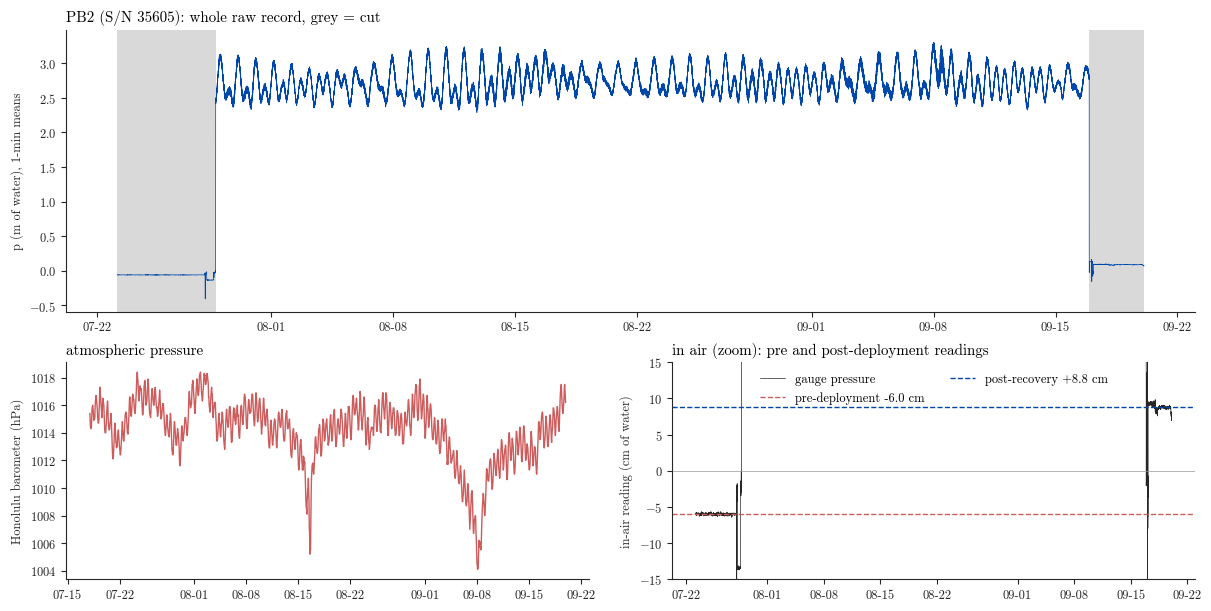

In [8]:
##-----figure: trim window + atmospheric correction-----##
M = 1e4 / (RHO * GRAV)    # dbar -> m of water
pm_c = pd.Series(p, index=tt).resample("1min").mean()
fig, axs = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True, gridspec_kw={"height_ratios": [1.3, 1]})
ax = fig.add_subplot(axs[0, 0].get_gridspec()[0, :]); axs[0, 0].remove(); axs[0, 1].remove()
ax.plot(pm_c.index, pm_c.values * M, color=BLUE, lw=0.5)
ax.axvspan(pm_c.index[0], t_in, color="0.85", lw=0); ax.axvspan(t_out, pm_c.index[-1], color="0.85", lw=0)
ax.set_ylabel("p (m of water), 1-min means"); ax.set_title(f"{sensor_id} (S/N {serial}): whole raw record, grey = cut", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[1, 0]
ax.plot(atm["Date Time"], atm["Pressure"], color=RED, lw=1.0)
ax.set_ylabel("Honolulu barometer (hPa)"); ax.set_title("atmospheric pressure", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[1, 1]
ax.plot(pm.index, (pm.values) * M * 100, color=INK, lw=0.5, label="gauge pressure")
ax.set_ylim(-15, 15); ax.axhline(0, color="0.6", lw=0.5)
ax.axhline(C_pre * M * 100, color=RED, ls="--", lw=1.0, label=f"pre-deployment {C_pre * M * 100:+.1f} cm")
ax.axhline(C_post * M * 100, color=BLUE, ls="--", lw=1.0, label=f"post-recovery {C_post * M * 100:+.1f} cm")
ax.set_ylabel("in-air reading (cm of water)"); ax.set_title("in air (zoom): pre and post-deployment readings", loc="left")
ax.legend(frameon=False, loc="upper center", ncol=2); ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_trim.png", dpi=150)
plt.show()

#### 4b. Tide-gauge check of the corrected clock (coarse)
Cross-correlate the sensor's tide (1-min mean water level from $p$) with the NOAA CO-OPS 6-min water level at Honolulu 1612340. A lag near 0 confirms the clock is UTC with no time-zone error; it cannot resolve seconds. The within-hour timing (fs) was checked separately, see 1b.

tide lag PB2 vs Honolulu: -1 min (r = 0.9829); tidal amplitude ratio sensor/gauge = 1.024


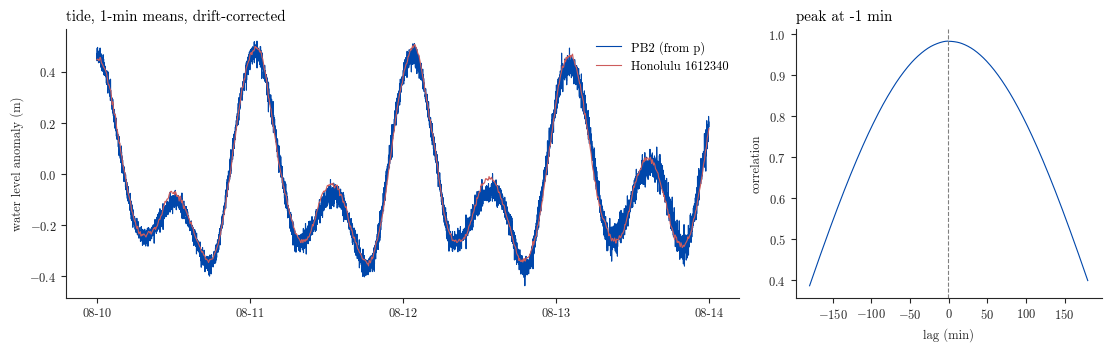

In [9]:
##-----tide-gauge check: coarse clock / time-zone test-----##
wl = pd.read_csv(root / "data" / "metadata" / "noaa_1612340_water_level.csv", skipinitialspace=True,
                 parse_dates=["Date Time"]).dropna(subset=["Water Level"])
gauge = wl.set_index("Date Time")["Water Level"]

eta = pd.Series(p[keep] * M, index=tt[keep]).resample("1min").mean()
g_i = pd.Series(np.interp(eta.index.values.astype("int64"), gauge.index.values.astype("int64"), gauge.values), index=eta.index)
eta_a, g_a = eta - eta.mean(), g_i - g_i.mean()
lags = np.arange(-180, 181)
r = np.array([eta_a.corr(g_a.shift(L)) for L in lags])
best = lags[np.argmax(r)]
print(f"tide lag {sensor_id} vs Honolulu: {best:+d} min (r = {r.max():.4f}); tidal amplitude ratio sensor/gauge = {eta_a.std() / g_a.std():.3f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True, gridspec_kw={"width_ratios": [2.2, 1]})
w = slice("2026-08-10", "2026-08-13")
axs[0].plot(eta_a[w].index, eta_a[w].values, color=BLUE, label=f"{sensor_id} (from p)")
axs[0].plot(g_a[w].index, g_a[w].values, color=RED, label="Honolulu 1612340")
axs[0].set_ylabel("water level anomaly (m)"); axs[0].set_title("tide, 1-min means, drift-corrected", loc="left")
axs[0].legend(frameon=False); axs[0].xaxis.set_major_locator(mdates.DayLocator()); axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axs[1].plot(lags, r, color=BLUE); axs[1].axvline(best, color="0.5", ls="--", lw=0.8)
axs[1].set_xlabel("lag (min)"); axs[1].set_ylabel("correlation"); axs[1].set_title(f"peak at {best:+d} min", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_clock_tide.png", dpi=150)
plt.show()

### 5. Hourly segment flags
One segment per raw file, labeled by the nominal file start (the logger's hour). That is the natural unit here: the 16.5 s file-to-file gap falls between segments, and the few-second drift shift cannot push samples into a neighbouring hour. A segment is good (`seg_ok`) only if all of the following hold:
- `frac` $\geq$ `SEG_MIN_FRAC`: it has at least 99 % of a full file's samples (partial hours at deployment and recovery fail);
- no gap larger than `GAP_MAX_S` inside the segment;
- no decode errors (`n_bad` = 0): a sample is flagged in `p_decode_flag` if its tick-wrap count differs from the record's modal value (counter / unwrap error) or the decode is not finite. Flagged samples are **never NaN'd or replaced**. A step threshold is deliberately not used: on the reef flat bores give steps up to 0.8 dbar in 0.5 s, and the step sizes are a smooth tail with no separate glitch population (PB1: all 10.1 M samples have the same wrap count). The largest step per hour is stored as `max_step` for inspection;
- the mean depth is positive and the pressure is finite.

`Hs_SS` is $4\sqrt{m_0}$ of the pressure spectrum (as m of water) over 0.04–0.25 Hz, **without** the depth transfer function, the same definition as `Hs_SS` in the ADV files. It is a diagnostic here and does not gate `seg_ok`; the Paros are only 1–3 m deep, so the uncorrected value is biased low in the sea-swell band. `adv_QCBulk.ipynb` / granolas apply the $\cosh(kh)$ correction.

In [10]:
##-----decode flag + hourly segment flags-----##
pk = p[keep]; tk = t[keep]; fk = fidx[keep]; tempk = temp[keep]
bad = ((k_wrap[keep] != k_mode) | ~np.isfinite(pk)).astype(np.int8)
dp = np.abs(np.diff(pk, prepend=pk[0]))
dp[np.r_[True, np.diff(fk) != 0]] = 0          # no step across a file boundary (16.5 s apart)
print(f"decode flags: {bad.sum()} samples; largest sample-to-sample step {np.nanmax(dp):.3f} dbar (diagnostic only)")

z_p = Z_P_HAB.get(sensor_id, Z_P_HAB["default"])
seg_files = np.unique(fk)
rows = []
for fi in seg_files:
    m = fk == fi
    x = pk[m]; tx = tk[m]
    n = int(m.sum())
    gap = float(np.max(np.diff(tx)) / np.timedelta64(1, "s")) if n > 1 else np.inf
    dep = float(np.nanmean(x) * M + z_p) if n else np.nan
    hs = np.nan
    if n >= 2 * WELCH_NFFT and np.isfinite(x).all():
        f_w, S = welch(x * M, fs=FS_NOM, window="hann", nperseg=WELCH_NFFT, noverlap=WELCH_NFFT // 2, detrend="linear")
        b = (f_w >= F_SS[0]) & (f_w <= F_SS[1])
        hs = 4 * np.sqrt(np.trapz(S[b], f_w[b]))
    rows.append((file_start[fi], n, gap, int(bad[m].sum()), float(dp[m].max()) if n else np.nan, dep, hs))
hrs = pd.DataFrame(rows, columns=["hour", "n", "max_gap_s", "n_bad", "max_step", "depth_h", "Hs_SS"]).set_index("hour")
hrs["frac"] = hrs.n / N_FILE
hrs["frac_ok"] = hrs.frac >= SEG_MIN_FRAC
hrs["gap_ok"] = hrs.max_gap_s <= GAP_MAX_S
hrs["decode_ok"] = hrs.n_bad == 0
hrs["depth_ok"] = hrs.depth_h > 0
hrs["seg_ok"] = hrs.frac_ok & hrs.gap_ok & hrs.decode_ok & hrs.depth_ok & hrs.Hs_SS.notna()
print(f"{len(hrs)} segments, {int(hrs.seg_ok.sum())} good ({100 * hrs.seg_ok.mean():.1f} %)")
print("failed by test:", {c: int((~hrs[c]).sum()) for c in ["frac_ok", "gap_ok", "decode_ok", "depth_ok"]})
print(f"depth_h {hrs.depth_h[hrs.seg_ok].min():.2f} / {hrs.depth_h[hrs.seg_ok].median():.2f} / {hrs.depth_h[hrs.seg_ok].max():.2f} m (min/median/max); "
      f"Hs_SS {hrs.Hs_SS[hrs.seg_ok].min():.2f} - {hrs.Hs_SS[hrs.seg_ok].max():.2f} m")
pgood = pk[np.isin(fk, np.flatnonzero(np.isin(file_start, hrs.index[hrs.seg_ok].values)))]
print(f"min p over seg_ok hours {pgood.min():.3f} dbar (all kept samples: {pk.min():.3f}); the low samples are splash / lift in the failed edge hours")
hrs[~hrs.seg_ok]

decode flags: 0 samples; largest sample-to-sample step 0.601 dbar (diagnostic only)


1204 segments, 1202 good (99.8 %)
failed by test: {'frac_ok': 2, 'gap_ok': 0, 'decode_ok': 0, 'depth_ok': 0}
depth_h 2.41 / 2.74 / 3.28 m (min/median/max); Hs_SS 0.51 - 1.09 m
min p over seg_ok hours 1.960 dbar (all kept samples: -0.073); the low samples are splash / lift in the failed edge hours


,n,max_gap_s,n_bad,max_step,depth_h,Hs_SS,frac,frac_ok,gap_ok,decode_ok,depth_ok,seg_ok
hour,,,,,,,,,,,,
2026-07-28 19:00:00,5227,0.5,0,0.482119,2.487990,0.708262,0.729315,False,True,True,True,False
2026-09-16 22:00:00,2971,0.5,0,0.362914,2.789319,0.677794,0.414539,False,True,True,True,False


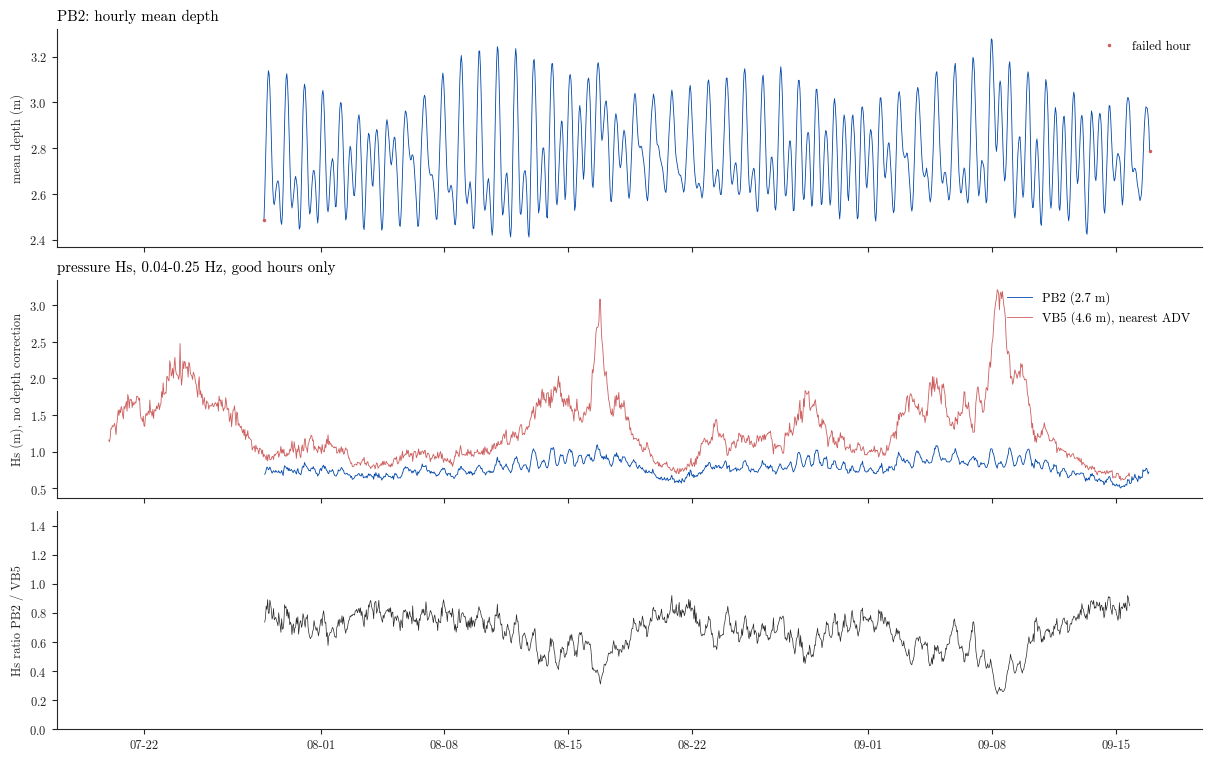

Hs_SS ratio PB2/VB5: median 0.69 (5-95 % 0.44-0.84), n 1176


In [11]:
##-----figure: hourly depth and Hs, and comparison with the nearest ADV-----##
adv_id = NEAREST_ADV[sensor_id]
adv = xr.open_dataset(qc_dir / f"{adv_id}_QC.nc")[["Hs_SS", "depth_h", "seg_ok"]].load()
ah = adv.to_dataframe()
fig, axs = plt.subplots(3, 1, figsize=(12, 7.5), constrained_layout=True, sharex=True)
good = hrs.seg_ok
axs[0].plot(hrs.index, hrs.depth_h, color=BLUE, lw=0.6)
axs[0].plot(hrs.index[~good], hrs.depth_h[~good], ".", color=RED, ms=3, label="failed hour")
axs[0].set_ylabel("mean depth (m)"); axs[0].legend(frameon=False, loc="upper right")
axs[0].set_title(f"{sensor_id}: hourly mean depth", loc="left")
axs[1].plot(hrs.index[good], hrs.Hs_SS[good], color=BLUE, lw=0.6, label=f"{sensor_id} ({hrs.depth_h[good].median():.1f} m)")
axs[1].plot(ah.index[ah.seg_ok.astype(bool)], ah.Hs_SS[ah.seg_ok.astype(bool)], color=RED, lw=0.6,
            label=f"{adv_id} ({ah.depth_h[ah.seg_ok.astype(bool)].median():.1f} m), nearest ADV")
axs[1].set_ylabel("Hs (m), no depth correction"); axs[1].legend(frameon=False, loc="upper right")
axs[1].set_title("pressure Hs, 0.04-0.25 Hz, good hours only", loc="left")
adv_ok = ah.seg_ok.astype(bool).reindex(hrs.index, fill_value=False)
ratio = (hrs.Hs_SS / ah.Hs_SS.reindex(hrs.index))[good & adv_ok]
axs[2].plot(ratio.index, ratio.values, color=INK, lw=0.5)
axs[2].set_ylabel(f"Hs ratio {sensor_id} / {adv_id}"); axs[2].set_ylim(0, 1.5)
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_hourly.png", dpi=150)
plt.show()
print(f"Hs_SS ratio {sensor_id}/{adv_id}: median {ratio.median():.2f} (5-95 % {ratio.quantile(.05):.2f}-{ratio.quantile(.95):.2f}), n {len(ratio)}")

### 6. Final product: `{site}_QC.nc`
`data/processed/qc/{site}_QC.nc`, the only output (the disk is nearly full, no intermediates). Layout follows the ADV files:
- 2 Hz (`time`, drift-corrected, in-water window only; **not a uniform grid**: 7167 samples per file, then a 16.5 s gap every hour): `p` (dbar, gauge; in-air offset removed only if `APPLY_AIR_OFFSET`), `p_raw` (dbar, absolute), `patm` (dbar), `temp` (°C), `p_decode_flag` (1 = tick-wrap count differs from the modal value, or decode not finite).
- Hourly (`hour`, nominal file start): `seg_ok`, its component tests, `n`, `frac`, `max_gap_s`, `n_bad`, `max_step` (diagnostic), `depth_h`, `Hs_SS`.
- Every QC choice is in the global attributes (`qc_*`, `seg_*`).

In [12]:
##-----save: final QC product-----##
qc = xr.Dataset(
    {"p": ("time", pk.astype("float32"), {"units": "dbar", "long_name": "gauge pressure: absolute - Honolulu barometer"
                                          + (" - pre-deployment in-air offset" if APPLY_AIR_OFFSET else "")}),
     "p_raw": ("time", p_abs[keep].astype("float32"), {"units": "dbar", "long_name": "absolute pressure from the Paroscientific calibration"}),
     "patm": ("time", patm[keep].astype("float32"), {"units": "dbar", "long_name": "NOAA 1612340 barometer, interpolated"}),
     "temp": ("time", tempk.astype("float32"), {"units": "degC", "long_name": "Paroscientific transducer temperature"}),
     "p_decode_flag": ("time", bad, {"long_name": "1 = tick-wrap count differs from the record's modal value or decode not finite (flag only, nothing replaced)"}),
     "seg_ok": ("hour", hrs.seg_ok.values, {"long_name": "good hour: frac_ok & gap_ok & decode_ok & depth_ok & finite Hs"}),
     "frac_ok": ("hour", hrs.frac_ok.values), "gap_ok": ("hour", hrs.gap_ok.values),
     "decode_ok": ("hour", hrs.decode_ok.values), "depth_ok": ("hour", hrs.depth_ok.values),
     "n": ("hour", hrs.n.values.astype("int32"), {"long_name": "samples in the segment after the trim"}),
     "frac": ("hour", hrs.frac.values.astype("float32"), {"long_name": f"n / {N_FILE}"}),
     "max_gap_s": ("hour", hrs.max_gap_s.values.astype("float32"), {"units": "s", "long_name": "largest gap inside the segment"}),
     "n_bad": ("hour", hrs.n_bad.values.astype("int32")),
     "max_step": ("hour", hrs.max_step.values.astype("float32"), {"units": "dbar", "long_name": "largest sample-to-sample step in the segment (diagnostic, bores give real steps)"}),
     "depth_h": ("hour", hrs.depth_h.values.astype("float32"), {"units": "m", "long_name": f"mean p (m of water, rho {RHO:g}, g {GRAV:g}) + z_p"}),
     "Hs_SS": ("hour", hrs.Hs_SS.values.astype("float32"),
               {"units": "m", "long_name": f"Hs from the pressure spectrum, {F_SS[0]}-{F_SS[1]} Hz, no depth correction"})},
    coords={"time": tk, "hour": hrs.index.values})
qc.attrs.update({
    "sensor_id": sensor_id, "logger_folder": folder, "serial": serial, "fs": FS_NOM,
    "qc_notebook": "processing/paros_processing.ipynb",
    "qc_decode": "counts -> psia, calibration from header.dat, checked against PAR*.DAT (max |dP| %.1e psi)" % checked[1],
    "qc_clock_drift_s": drift, "qc_clock_drift_convention": "+ = sensor clock fast; t_true = t - drift * frac_elapsed",
    "qc_clock_raw_start": str(t_raw0), "qc_clock_raw_end": str(t_raw1),
    "qc_clock_tide_lag_min": int(best),
    "qc_patm": "NOAA CO-OPS 1612340 Honolulu Harbor, hourly, linearly interpolated",
    "qc_air_offset_applied": int(APPLY_AIR_OFFSET), "qc_air_offset_pre_dbar": float(C_pre), "qc_air_offset_post_dbar": float(C_post),
    "qc_air_offset_post_minus_pre_dbar": float(-offset_drift), "qc_air_offset_note": "in-air reading depends on where the unit sat (pre and post differ by 11-15 cm); stored as a diagnostic, applied only if qc_air_offset_applied = 1",
    "qc_window_start": str(t_in), "qc_window_end": str(t_out), "qc_p_wet_dbar": P_WET, "qc_buffer_s": BUFFER_S,
    "qc_trim_note": "no heading-based handling trim (no compass)",
    "qc_despike": "none; decode errors are flagged only",
    "time_note": "NOT a uniform 2 Hz grid: each hourly file holds 7167 samples (3583.5 s) and the next file starts on the hour, so there is a 16.5 s gap every hour. Use the time coordinate, not the index, and interpolate onto common times for cross-spectra with other sensors",
    "seg_definition": "one segment per raw file (nominal hour)", "seg_min_frac": SEG_MIN_FRAC, "seg_gap_max_s": GAP_MAX_S,
    "seg_decode_k_mode": k_mode, "seg_welch_nfft": WELCH_NFFT, "seg_hs_band_hz": list(F_SS),
    "seg_ok_pct": float(100 * hrs.seg_ok.mean()), "z_p_m": z_p, "rho": RHO, "grav": GRAV,
    "zt_note": "z2 test not applied (no co-located velocity)",
})
enc = {v: {"zlib": True, "complevel": 4} for v in qc.data_vars}
enc["time"] = {"zlib": True, "complevel": 4}
out_path = qc_dir / f"{sensor_id}_QC.nc"
qc.to_netcdf(out_path, encoding=enc)
print(f"saved {out_path}  ({out_path.stat().st_size / 1e6:.0f} MB)")

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/PB2_QC.nc  (50 MB)


### Run the other sites
Off by default. Save the notebook (the cell reads it from disk), set `RUN_BATCH = True` in the cell below and run that cell on its own. Each site runs in a fresh kernel and the executed copy is written to `processing/qc_runs/paros_processing_{SITE}.ipynb`.